<a href="https://colab.research.google.com/github/amiraatbk/Neural-network-kntu-/blob/HW3/HW3AmirAtabaki9923413.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
844/844 - 141s - 167ms/step - accuracy: 0.9407 - loss: 0.2067 - val_accuracy: 0.9845 - val_loss: 0.0555
Epoch 2/10
844/844 - 139s - 164ms/step - accuracy: 0.9773 - loss: 0.0822 - val_accuracy: 0.9897 - val_loss: 0.0454
Epoch 3/10
844/844 - 145s - 171ms/step - accuracy: 0.9830 - loss: 0.0617 - val_accuracy: 0.9908 - val_loss: 0.0408
Epoch 4/10
844/844 - 137s - 162ms/step - accuracy: 0.9865 - loss: 0.0485 - val_accuracy: 0.9885 - val_loss: 0.0434
Epoch 5/10
844/844 - 141s - 167ms/step - accuracy: 0.9889 - loss: 0.0399 - val_accuracy: 0.9895 - val_loss: 0.0459
Epoch 6/10
844/844 - 140s - 166ms/step - accuracy: 0.9891 - loss: 0.0395 - val_accuracy: 0.9900 - val_loss: 0.0531
Epoch 7/10
844/844 - 141s - 167ms/step - accuracy: 0.9909 - loss: 0.0334 - val_accuracy: 0.9893 - val_loss: 0.0594
Epoch 8/10
844/844 - 142s - 168ms/step - accuracy: 0.9922 - loss: 0.0280 - val_accuracy: 0.9917 - val_loss: 0.0427
Epoch 9/10
844/844 - 133s - 1

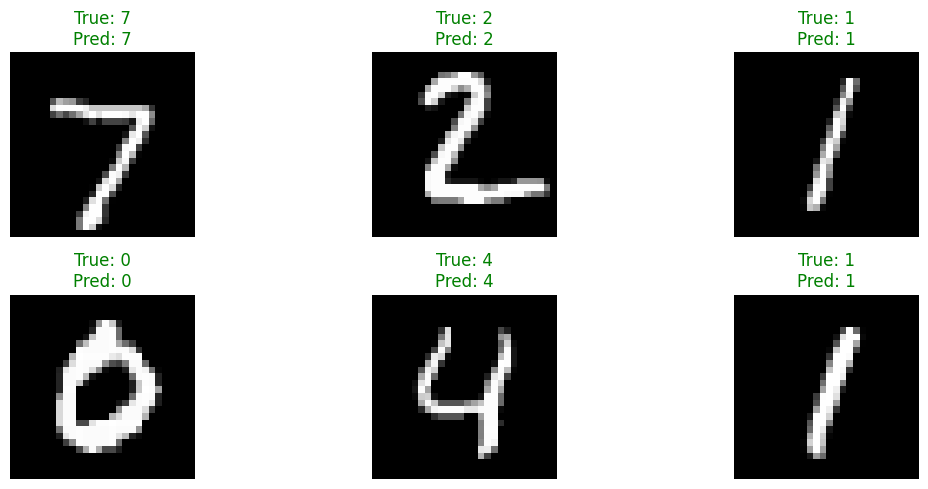

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

# 1. Load and preprocess data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, axis=-1)  # shape -> (batch, 28, 28, 1)
x_test = np.expand_dims(x_test, axis=-1)

# 2. Define model using Functional API
inputs = Input(shape=(28, 28, 1))

x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)

x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs, outputs)

# 3. Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. Train model
history = model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    verbose=2
)

# 5. Evaluate model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

# 6. Predict and visualize
predictions = model.predict(x_test)

def show_predictions(images, labels, predictions, num=6):
    plt.figure(figsize=(12, 5))
    for i in range(num):
        plt.subplot(2, num//2, i+1)
        plt.imshow(images[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
        true_label = labels[i]
        pred_label = np.argmax(predictions[i])
        color = "green" if true_label == pred_label else "red"
        plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.tight_layout()
    plt.show()

show_predictions(x_test, y_test, predictions)
